In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('data/criteo/criteo-uplift-v2.1.csv')

### **T-Learner**

Выбор класса модели исходит из особенностей, выявленных в результате анализа датасета:

    Данные получены в результате рандомизированного эксперимента с двумя группами – экспериментальной и контрольной,
    Между группами наблюдается значительный дисбаланс (85/15),
    Встречаются признаки с высокой корреляцией и выбросами,
    Цель моделирования – оценка чистого эффекта воздействия на клиентов (uplift),
    Базовая конверсия низкая.
            
Наиболее оптимальным вариантом является использование двухмодельного подхода T-Learner:

    Обучаются две независимые модели для экспериментальной и контрольной групп,
    Разделение позволяет снизить ошибки, связанные с дисбалансом между группами и редкостью целевых событий,
    Подход относительно устойчив к выбросам и коррелирующим данным,
    Модель при необходимости можно расширить
    
Пользователи теоретически могут принадлежать к четырем группам на основе их потенциальных результатов: "Не беспокоить" (Do-Not-Disturbs) - негативная реакция на воздействие, "Потерянный" (Lost Causes) - не совершит целевое действие в любом случае, "Лояльный" (Sure Things) - положительная реакция в любом случае, и "Убеждаемый" (Persuadables) - положительно реагирует на воздействие. Главной целью моделирования является поиск группы Убеждаемых, таргет на которых полностью окупится.

Расширение модели и использование других подходов могут быть полезны для сравнения их эффективности, однако для ориентировочной оценки достаточно T-Learner. В данном проекте будет рассмотрен только этот подход.

Для упрощенного расчета uplift-метрик и моделирования можно использовать библиотеку sklift, но для более гибкой настройки и практики они будут реализованы вручную.

**Разбиение данных по treatment**

In [3]:
X = df[[f"f{i}" for i in range(12)]].values # признаки
y = df["conversion"].values # целевое событие
T = df["treatment"].values # экспериментальная группа

Доля тестовой выборки 30% - достаточный объём для устойчивой оценки.
Разбиение данных выполнено со стратификацией по treatment для сохранения пропорций экспериментальной и контрольной групп в обучающей и тестовой выборках.

In [4]:
X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
    X, y, T,
    test_size=0.3,
    random_state=42,
    stratify=T
)

In [5]:
print(f"Обучающая группа: {X_train.shape}")
print(f"Тестовая группа: {X_test.shape}")

Обучающая группа: (9785714, 12)
Тестовая группа: (4193878, 12)


**Стандартизация**

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# вынужденная мера для экономии памяти, не влияет на результат
X_train_sc = X_train_sc.astype("float32")
X_test_sc  = X_test_sc.astype("float32")

In [7]:
X_train_treat = X_train_sc[T_train == 1]
y_train_treat = y_train[T_train == 1]

X_train_ctrl = X_train_sc[T_train == 0]
y_train_ctrl = y_train[T_train == 0]

**Обучение моделей через логистическую регрессию**

Для реализации T-Learner используется логистическая регрессия - она устойчива к редким событиям, обеспечивает хорошо калиброванные оценки и напрямую моделирует вероятность бинарного исхода - это необходимо для моделирования, поскольку итоговый эффект определяется как разность двух прогнозов.

In [8]:
# для экспериментальной группы
model_treat = LogisticRegression(
    penalty="l2",
    C=0.1,
    class_weight="balanced",
    max_iter=500,
    n_jobs=-1
)

# для контрольной группы
model_ctrl = LogisticRegression(
    penalty="l2",
    C=0.1,
    class_weight="balanced",
    max_iter=500,
    n_jobs=-1
)

model_treat.fit(X_train_treat, y_train_treat)
model_ctrl.fit(X_train_ctrl, y_train_ctrl)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=500, n_jobs=-1)

In [10]:
print(f"Сходимость treat модели: {model_treat.n_iter_}")
print(f"Сходимость ctrl модели: {model_ctrl.n_iter_}")

Сходимость treat модели: [24]
Сходимость ctrl модели: [21]


**Вычисление uplift**

In [11]:
p_treat = model_treat.predict_proba(X_test_sc)[:, 1]
p_ctrl = model_ctrl.predict_proba(X_test_sc)[:, 1]

uplift = p_treat - p_ctrl

In [19]:
results = pd.DataFrame({
    "treatment": T_test,
    "conversion": y_test,
    "p_treat": p_treat,
    "p_ctrl": p_ctrl,
    "uplift": uplift
})

print(results.head())

   treatment  conversion   p_treat    p_ctrl    uplift
0          1           0  0.040380  0.043583 -0.003203
1          1           0  0.114593  0.127142 -0.012549
2          1           0  0.056685  0.059870 -0.003184
3          1           0  0.489520  0.544497 -0.054976
4          1           0  0.077430  0.078297 -0.000867


### **Анализ результатов**

In [21]:
results["uplift"].describe()

count    4.193878e+06
mean    -2.648656e-03
std      2.037141e-02
min     -1.698593e-01
25%     -4.966687e-03
50%     -3.110606e-03
75%     -2.730709e-04
max      2.867117e-01
Name: uplift, dtype: float64

В среднем воздействие оказывается убыточным, но близким к нулю (mean = -0.26%). Это может быть связано с наличием как неподходящих, так и подходящих клиентов для показа рекламы: негативное воздействие (min = -17.0%) относится к клиентам типа Не беспокоить, положительное воздействие (max = +28.7%) относится к клиентам типа Убеждаемые.

Верхний квартиль содержит клиентов с uplift > -0.03% - это группа клиентов, на которую действительно выгодно ориентировать рекламу.

In [22]:
(results["uplift"] > 0).mean()

0.23893255836245117

Конкретно 23.89% клиентов имеют положительный uplift, на них необходимо ориентироваться.

In [23]:
results.sort_values("uplift", ascending=False).head(10)

,treatment,conversion,p_treat,p_ctrl,uplift
697078,1,0,0.548906,0.262194,0.286712
931777,1,0,0.520327,0.272494,0.247833
652170,1,0,0.606803,0.360339,0.246464
2753869,1,0,0.549375,0.303434,0.245941
2399176,0,0,0.580334,0.337051,0.243282
647553,1,0,0.540842,0.298310,0.242532
3760555,1,0,0.523129,0.285969,0.237160
143018,1,0,0.617687,0.380716,0.236972
184147,1,0,0.746647,0.510366,0.236280
2710055,1,0,0.582592,0.346457,0.236135


В топе пользователей с высоким uplift видно, что вероятность отклика при воздействии значительно выше (от 52%), чем без (от 26%) - это значит, что реклама для этих пользователей должна быть действительно полезной. Они имеют признаки клиентов с высоким откликом, и на них стоит ориентироваться при таргетинге, несмотря на то, что конверсии не случилось.

**Qini curve**

In [16]:
import matplotlib.pyplot as plt

In [76]:
# сортировка по uplift и обнуление индекса
qini_df = (results.sort_values("uplift", ascending=False).reset_index(drop=True))

# конверсии
qini_df["treated_conv"] = qini_df["conversion"] * qini_df["treatment"]
qini_df["control_conv"] = qini_df["conversion"] * (1 - qini_df["treatment"])

# кумулятивные суммы
qini_df["cum_treat_conv"] = qini_df["treated_conv"].cumsum()
qini_df["cum_ctrl_conv"]  = qini_df["control_conv"].cumsum()

# коррекция, нужна из-за сильного дисбаланса treatment/control
treat_rate = qini_df["treatment"].mean()
ctrl_rate  = 1 - treat_rate
ratio = treat_rate / ctrl_rate

# значение qini
qini_df["qini"] = qini_df["cum_treat_conv"] - ratio * qini_df["cum_ctrl_conv"]

In [82]:
qini_df['share_users'] = np.arange(len(qini_df)) / len(qini_df)
qini_df['baseline'] = qini_df['share_users'] * qini_df["qini"].iloc[-1]

# коэффициент AUC
qini_auc = np.trapz(qini_df["qini"].values - qini_df['baseline'].values, qini_df['share_users'])
print(f"Qini AUC: {qini_auc:.4f}")

Qini AUC: 553.5021


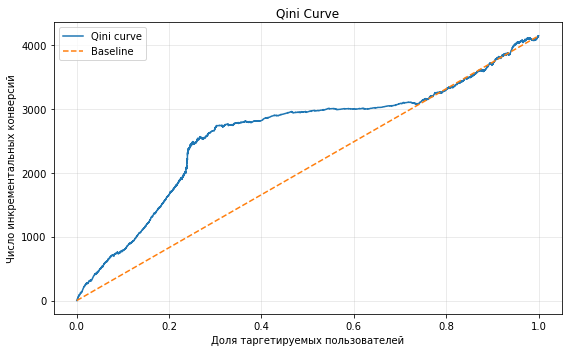

In [83]:
plt.figure(figsize=(8, 5))
plt.plot(qini_df['share_users'], qini_df["qini"].values, label="Qini curve")
plt.plot(qini_df['share_users'], qini_df['baseline'], "--", label="Baseline")
plt.xlabel("Доля таргетируемых пользователей")
plt.ylabel("Число инкрементальных конверсий")
plt.title("Qini Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Пользователи отсортированы по убыванию предсказанного uplift.

Высокое значение AUC (area under curve) для Qini - полученная uplift-модель превосходит случайную.

На кривой Qini, изображенной на графике, можно выделить три ключевых сегмента:

    0-30% - убеждаемые пользователи: лучшие для таргета.
    После 30% - "слабые" убеждаемые, пик эффективности заканчивается, кривая начинает сближаться с baseline.
    После 70% - таргетирование теряет смысл, нет отличия от случайного таргета, кривая пересекается с baseline.
    
Топ-30% пользователей дают ~60% инкрементального эффекта.

**uplift@k**

In [60]:
uplift_at_k = []

# сортировка по uplift и обнуление индекса
k_df = results.sort_values("uplift", ascending=False).reset_index(drop=True)

# топ‑K% строк по uplift
for k in [0.2, 0.3, 0.5, 0.7]:
    top_k = k_df.iloc[:int(k * len(k_df))]

    uplift_k = (
        top_k.loc[top_k["treatment"] == 1, "conversion"].mean()
        - top_k.loc[top_k["treatment"] == 0, "conversion"].mean()
    )

    uplift_at_k.append({
        "K_share": k, # доля таргетируемых пользователей
        "K_percent": int(k * 100), # в процентах
        "uplift": uplift_k
    })

uplift_at_k = pd.DataFrame(uplift_at_k)
uplift_at_k

,K_share,K_percent,uplift
0,0.2,20,0.002229
1,0.3,30,0.002395
2,0.5,50,0.001616
3,0.7,70,0.001223


Размер uplift на топ-k процентах выборки. Выбор K исходил из результатов Qini Curve.

Модель демонстрирует наибольшую эффективность при таргетировании верхних 20–30% пользователей, ранжированных по прогнозируемому uplift. От 50% и выше эффект быстро деградирует.

**Uplift by percentile**

In [61]:
# сортировка по uplift и обнуление индекса
pct_df = (results.sort_values("uplift", ascending=False).reset_index(drop=True))

# разделение на 10 равных групп по рангу uplift
pct_df["percentile"] = pd.qcut(pct_df.index / len(pct_df), q=10, labels=False)

uplift_pct = (pct_df.groupby("percentile").apply(lambda g: pd.Series({
    "n_treat": (g["treatment"] == 1).sum(),
    "n_ctrl":  (g["treatment"] == 0).sum(),
    "resp_treat": g.loc[g["treatment"] == 1, "conversion"].mean(),
    "resp_ctrl":  g.loc[g["treatment"] == 0, "conversion"].mean()
    }))
)

uplift_pct["uplift"] = uplift_pct["resp_treat"] - uplift_pct["resp_ctrl"]

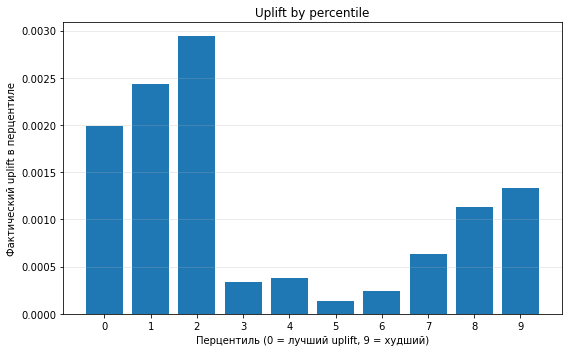

In [62]:
x = np.arange(len(uplift_pct))

plt.figure(figsize=(8, 5))
plt.bar(x, uplift_pct["uplift"])
plt.xticks(x, uplift_pct.index)
plt.xlabel("Перцентиль (0 = лучший uplift, 9 = худший)")
plt.ylabel("Фактический uplift в перцентиле")
plt.title("Uplift by percentile")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Пользователи отсортированы по убыванию предсказанного uplift.

Подтверждаются результаты предыдущих метрик - первые 3 дециля (топ-30%) дают основной эффект, это убеждаемые пользователи. Пользователи из остальных перцентилей демонстрируют меньшую эффективность при таргетировании и не рекомендуются для воздействия.

In [63]:
stats = (pct_df.groupby("percentile").apply(lambda g: pd.Series({
    "treat_rr": g.loc[g["treatment"] == 1, "conversion"].mean(),
    "ctrl_rr":  g.loc[g["treatment"] == 0, "conversion"].mean()
    }))
)

stats["uplift"] = stats["treat_rr"] - stats["ctrl_rr"]

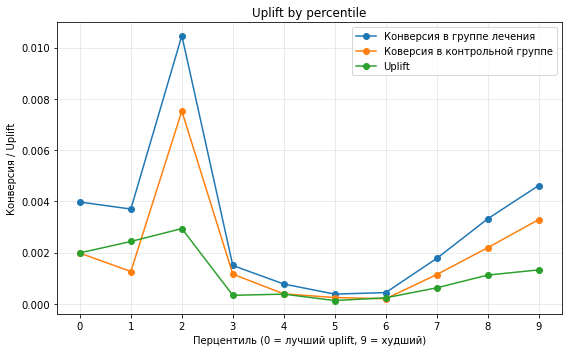

In [64]:
x = np.arange(10)

plt.figure(figsize=(8, 5))
plt.plot(x, stats["treat_rr"], marker="o", label="Конверсия в группе лечения")
plt.plot(x, stats["ctrl_rr"],  marker="o", label="Коверсия в контрольной группе")
plt.plot(x, stats["uplift"],   marker="o", label="Uplift")
plt.xticks(x, stats.index)
plt.xlabel("Перцентиль (0 = лучший uplift, 9 = худший)")
plt.ylabel("Конверсия / Uplift")
plt.title("Uplift by percentile")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Визуализация предыдущей метрики методом line plot - более наглядно демонстрирует Uplift как разницу конверсий контрольной группы и группы treatment. Инкрементальный эффект в первых трех перцентилях +0.2-0.3%, затем идет резкий спад.

In [42]:
# общий uplift
overall_uplift = (
    results.loc[results["treatment"] == 1, "conversion"].mean()
    - results.loc[results["treatment"] == 0, "conversion"].mean()
)
print(overall_uplift)

0.0011622889860243568


Overall uplift = 0.001162, примерно равен ITT (0.001152) из прошлых расчётов. Это означает, что модель откалибрована правильно и не должна иметь значимых отклонений при оценивании эффекта.

In [85]:
# индикатор "узких" групп, где uplift может быть нестабильным
uplift_pct["min_group"] = uplift_pct[["n_treat", "n_ctrl"]].min(axis=1)
print(uplift_pct[["uplift", "n_treat", "n_ctrl", "min_group"]])

              uplift   n_treat   n_ctrl  min_group
percentile                                        
0           0.001993  361402.0  57986.0    57986.0
1           0.002437  356988.0  62400.0    62400.0
2           0.002940  356401.0  62987.0    62987.0
3           0.000338  355761.0  63626.0    63626.0
4           0.000384  355942.0  63446.0    63446.0
5           0.000133  355794.0  63594.0    63594.0
6           0.000241  355589.0  63798.0    63798.0
7           0.000630  355739.0  63649.0    63649.0
8           0.001127  355597.0  63791.0    63791.0
9           0.001329  355584.0  63804.0    63804.0


Метрики с локальными оценками по перцентилям (Uplift by Percentile) могут быть менее точными из-за дисбаланса между группами. Результаты Qini в данном случае являются более достоверными, поскольку эта метрика является кумулятивной - рассчитывается по накопленным данным, что сглаживает влияние малых групп.

**Сохранение результатов**

In [94]:
summary_metrics = pd.DataFrame([{
    "model": "T-Learner",
    "qini_auc": qini_auc,
    "overall_uplift": overall_uplift,
    "random_uplift": 0.001152, # ITT
    "optimal_k_share": 0.7,
    "best_k_share": 0.3,
    "share_negative_uplift": (results["uplift"] < 0).mean(),
}])

In [96]:
csv_dict = {
    "uplift_results.csv": results,
    "qini_curve.csv": qini_df[["qini","baseline","share_users"]],
    "top_at_k.csv": uplift_at_k,
    "uplift_by_pct.csv": uplift_pct.reset_index(),
    "summary_metrics.csv": summary_metrics
}

for filename, df in csv_dict.items():
    df.round(6).to_csv(filename, index=False)

### **РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ**

Модель успешно продемонстрировала способность различать наиболее эффективных для таргетинга пользователей, выделив Убеждаемых пользователей в топ-30% ранжирования по uplift, что подтверждено Qini Curve с AUC = 553.5 и анализом по перцентилям, где первые три перцетиля показывают значительный uplift при сравнении базовой конверсии в контрольной группе и конверсии в экспериментальной группе. Общий uplift (overall uplift) примерно равен ITT, что гарантирует качество калибровки предсказаний. Учитывая высокий дисбаланс (85/15) между экспериментальной и контрольной группами, оценки в перцентилях могут иметь повышенную дисперсию и снижать точность результата, но кумулятивные метрики, такие как Qini Curve, должны сгладить возможные ошибки. Также визуализация Qini Curve наиболее четко разделяет пользователей по эффекту. Топ-30% дают ~60% всего эффекта, превосходя случайный таргетинг.

Анализ топ-10 пользователей с максимальным uplift выявил следующие характеристики наиболее Убеждаемых пользователей:

    Вероятность конверсии при воздействии в ~2 раза выше, чем базовая.
    Несмотря на отсутствие фактических конверсий даже в treatment-группе, модель предсказывает высокий инкрементальный эффект от рекламы.
    Эти пользователи имеют признаки (f0-f11) клиентов с высокой вероятностью отклика. На эти признаки необходимо ориентироваться при таргетировании, такие пользователи имеют высокий потенциал.

Ключевые результаты:

    Топ-30% пользователей дают максимальный эффект uplift, ~60% от всего эффекта.
    Qini AUC = 553.5 - модель качественно ранжирует пользователей и выделяет группу Убеждаемых.
    Overall uplift ≈ ITT - корректная калибровка модели, высокое доверие к предсказаниям модели.
    Оценки по перцентилям имеют меньшую надежность, чем Qini Curve. При принятии решений лучше ориентироваться на результаты Qini.
    
Рекомендованная стратегия по результатам моделирования:

    Топ-10% - приоритетные пользователи, максимум инкрементальных конверсий. ("Сильные" Убеждаемые)
    Топ-30% - основной фокус. ("Слабые" Убеждаемые)
    >30% - снижение эффективности, таргетировать с осторожностью.
    >70% - не таргетировать. (Лояльные и Потерянные пользователи)
    
Рекомендованная стратегия с учетом анализа воронки, ITT/TOT и uplift-моделирования:

1. Увеличить exposure до желаемого эффекта - критическое слабое место воронки (TOT/ITT = 27.7). Необходим анализ каналов, видимости и д.р. для большей информации.
2. Таргетинг на топ-10% пользователей по модели uplift - пользователи типа Убеждаемые с инкрементальным эффектом +0.2%. Результат: вероятность конверсии растет в ~1.5-2 раза.
3. Таргетинг на топ-30% для дополнительного прироста - 60-70% всего эффекта по данным Qini.

! Приоритет - exposure, затем персонализация по uplift-ранжированию.

Вопросы и направления для дальнейших исследований:

1. Кластерная визуализация признаков и сопоставление результатов с uplift-квантилями, выявление паттернов Убеждаемых и других типов пользователей.
2. Как будут отличаться результаты при использовании других моделей (например: X-Learner, R-Learner, Uplift Random Forest)?